# Instruction Fine Tuning GPT2 model with a small dataset

Inspiration: https://github.com/rasbt/LLMs-from-scratch/blob/main/ch07/01_main-chapter-code/ch07.ipynb

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import os
import requests
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
from functools import partial
from transformers import AutoTokenizer, AutoModelForCausalLM
import math
from helper_functions import calc_loss_loader, train_model_simple, plot_values
import time

In [3]:
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [4]:
# Constants

PAD_TOKEN_ID = 50256
IGNORE_INDEX = -100
ALLOWED_MAX_LENGTH = 512
MODEL = "gpt2-medium"
NUM_WORKERS = 0
BATCH_SIZE = 4
LORA_RANK = 16
LORA_ALPHA = 32

In [5]:
def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        text_data = response.text
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)

    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    return data

In [6]:
data = download_and_load_file("instruction-data.json", "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch07/01_main-chapter-code/instruction-data.json")

In [7]:
print(type(data))
print(data[0])
print(data[-1])
print(len(data))

<class 'list'>
{'instruction': 'Evaluate the following phrase by transforming it into the spelling given.', 'input': 'freind --> friend', 'output': 'The spelling of the given phrase "freind" is incorrect, the correct spelling is "friend".'}
{'instruction': "Change the sentence 'You should have called me.' into a question.", 'input': '', 'output': 'Should you have called me?'}
1100


In [8]:
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

In [9]:
class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):

        self.data = data

        self.encoded_texts = []
        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(tokenizer.encode(
                full_text,
                truncation=True,
                max_length=ALLOWED_MAX_LENGTH
            ))

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.encoded_texts)

In [10]:
tokenizer = AutoTokenizer.from_pretrained(MODEL)
tokenizer.pad_token = tokenizer.eos_token  # GPT-2 has no pad token by default

In [11]:
train_size = int(len(data)*0.85)
test_size = int(len(data)*0.10)
val_size = len(data) - train_size - test_size

torch.manual_seed(42)
train_subset, test_subset, val_subset = random_split(
    data, [train_size, test_size, val_size])

In [12]:
# Custom collate function to be used in DataLoader
# Pads the sequences to the smaller between the allowed_max_length
# and the batch_max_length.
# Replace pad_token_id with ignore_index from targets, leave only the first one
# It is done to avoid computing the loss on padding tokens
def custom_collate(
    batch,
    pad_token_id,
    ignore_index,
    allowed_max_length=None,
    device="cpu"
):
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_list, targets_list = [], []
    
    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]

        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))

        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])
        
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index # leave the first pad_token_id (EOS) as is

        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_list.append(inputs)
        targets_list.append(targets)

    inputs_tensor = torch.stack(inputs_list).to(device)
    targets_tensor = torch.stack(targets_list).to(device)

    return inputs_tensor, targets_tensor

In [13]:
if torch.cuda.is_available():
    device = torch.device("cuda")

print("Device:", device)
print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA GeForce RTX 5070


In [14]:
custom_collate_fn = partial(
    custom_collate,
    pad_token_id=PAD_TOKEN_ID,
    ignore_index=IGNORE_INDEX,
    allowed_max_length=ALLOWED_MAX_LENGTH,
    device=device
)

In [15]:
train_dataset = InstructionDataset(train_subset, tokenizer)
train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    collate_fn=custom_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS
)
    
val_dataset = InstructionDataset(val_subset, tokenizer)
val_dataloader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    collate_fn=custom_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS
)

test_dataset = InstructionDataset(test_subset, tokenizer)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    collate_fn=custom_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS
)

In [16]:
model = AutoModelForCausalLM.from_pretrained(MODEL)

In [17]:
model.to(device)

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1024)
    (wpe): Embedding(1024, 1024)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-23): 24 x GPT2Block(
        (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=3072, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=1024)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=4096, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=4096)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=1024, out_features=50257, bias=False)
)

Let's test the model, it won't be able to follow instructions since it's only been trained to generate text.

In [18]:
model.eval()

formatted_sample = format_input(data[0])
inputs = tokenizer(formatted_sample, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=100,
        pad_token_id=tokenizer.eos_token_id,
    )

generated = outputs[0][inputs["input_ids"].shape[-1]:]
print(f"\n## Formated Sample: \n{formatted_sample}")
print(f"\n## Output: {tokenizer.decode(generated, skip_special_tokens=True)}")


## Formated Sample: 
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Evaluate the following phrase by transforming it into the spelling given.

### Input:
freind --> friend

## Output: 

### Output:

freind --> friend

### Instruction:

Evaluate the following phrase by transforming it into the spelling given.

### Input:

freind --> friend

### Output:

freind --> friend

### Instruction:

Evaluate the following phrase by transforming it into the spelling given.

### Input:

freind --> friend

### Output:

freind --> friend

###


Replace attention and projection matrixes with LoRA matrixes with rank 16 and alpha 32

In [19]:
class LoraLayer(torch.nn.Module):
    def __init__(self, in_dim, out_dim, r, alpha):
        super().__init__()
        self.r = r
        self.alpha = alpha
        self.A = torch.nn.Parameter(torch.empty(in_dim, r))
        torch.nn.init.kaiming_uniform_(self.A, a=math.sqrt(5))
        self.B = torch.nn.Parameter(torch.zeros(r, out_dim))

    def forward(self, x):
        return (self.alpha / self.r) * (x @ self.A @ self.B)

class LoraLinear(torch.nn.Module):
    def __init__(self, linear, rank, alpha):
        super().__init__()
        self.linear = linear
        
        # Handle both nn.Linear and Conv1D
        if hasattr(linear, 'in_features'):
            in_dim  = linear.in_features
            out_dim = linear.out_features
        else:
            in_dim  = linear.nx
            out_dim = linear.nf
            
        self.lora = LoraLayer(in_dim, out_dim, rank, alpha)

    def forward(self, x):
        return self.linear(x) + self.lora(x)
def replace_layers_with_lora(model, rank, alpha):
    for param in model.parameters():
        param.requires_grad = False

    for module in model.transformer.h:
        attn = module.attn
        attn.c_attn = LoraLinear(attn.c_attn, rank=rank, alpha=alpha)
        attn.c_proj = LoraLinear(attn.c_proj, rank=rank, alpha=alpha)

    return model

In [20]:
model = replace_layers_with_lora(model, rank=LORA_RANK, alpha=LORA_ALPHA)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

Trainable: 2,359,296 / 357,182,464 (0.66%)


In [21]:
model

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1024)
    (wpe): Embedding(1024, 1024)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-23): 24 x GPT2Block(
        (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): LoraLinear(
            (linear): Conv1D(nf=3072, nx=1024)
            (lora): LoraLayer()
          )
          (c_proj): LoraLinear(
            (linear): Conv1D(nf=1024, nx=1024)
            (lora): LoraLayer()
          )
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=4096, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=4096)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1024,)

In [22]:
model.to(device)

torch.manual_seed(42)
with torch.no_grad():
    train_loss = calc_loss_loader(train_dataloader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_dataloader, model, device, num_batches=5)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.722336483001709
Validation loss: 3.9553545475006104


In [23]:
start_time = time.time()

torch.manual_seed(42)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)

num_epochs = 2

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_dataloader, val_dataloader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_subset[0]), tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 3.547, Val loss 3.843
Ep 1 (Step 000200): Train loss 0.873, Val loss 0.872
Below is an instruction that describes a task. Write a response that appropriately completes the request.  ### Instruction: What is the boiling point of water under standard conditions?  ### Response: The boiling point of water is 212 degrees Fahrenheit.<|endoftext|>The following is an instruction that describes a task.  ### Instruction: What is the temperature of the sun at noon?  ### Response: The
Ep 2 (Step 000400): Train loss 0.691, Val loss 0.788
Below is an instruction that describes a task. Write a response that appropriately completes the request.  ### Instruction: What is the boiling point of water under standard conditions?  ### Response: The boiling point of water is 212 degrees Celsius.<|endoftext|>The following is an instruction manual for the game "The Sims 3: Complete Collection".  Contents show]  Walkthrough Edit  The game is set
Training completed in 0.35 minutes.


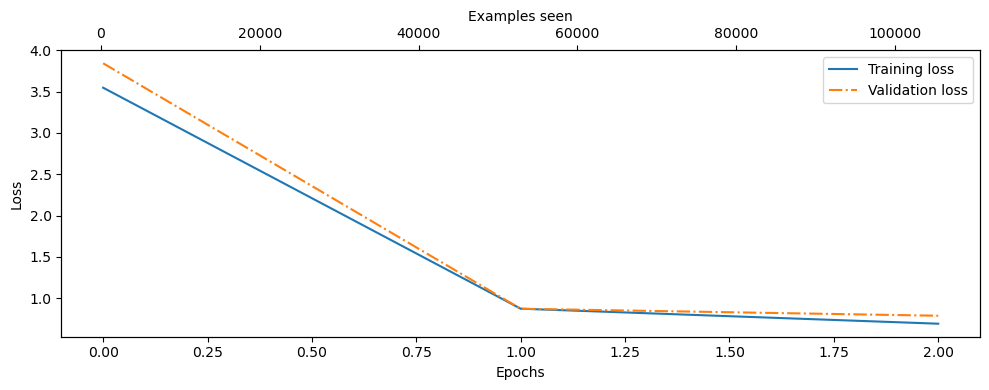

In [24]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_values(epochs_tensor, tokens_seen, train_losses, val_losses)

In [25]:
import re

file_name = f"{re.sub(r'[ ()]', '', MODEL) }-small-dataset-sft.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

Model saved as gpt2-medium-small-dataset-sft.pth
